# Sesión 7 — Aprendizaje no supervisado, clustering, PCA y visualización

## Objetivo del notebook

En este notebook vas a:

1. Aplicar **K-means** a una base conocida: `Iris`.
2. Construir una **gráfica de codo**.
3. Evaluar clusters con **inertia** y **silhouette score**.
4. Usar **PCA** para reducir dimensiones.
5. Visualizar los clusters en 2D.
6. Resolver ejercicios autónomos con una base de datos de **Pokémon**.

## Nota importante

En aprendizaje no supervisado **no usamos etiquetas para entrenar**.  
En este notebook, la etiqueta de Iris solo se usará al final para comparar visualmente, no para entrenar K-means.

## 1. Importar librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

## 2. Cargar la base Iris

La base `Iris` contiene mediciones de flores:

- largo del sépalo
- ancho del sépalo
- largo del pétalo
- ancho del pétalo

La variable `target` indica la especie, pero para clustering la vamos a guardar aparte.

In [2]:
iris = load_iris()

df = pd.DataFrame(iris.data, columns=iris.feature_names)
df["species"] = iris.target

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


## 3. Explorar los datos

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [4]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


### Preguntas de reflexión (responde aquí mismo)

1. ¿Cuántas variables numéricas tiene la base?
    > 4
2. ¿Qué representan las columnas?
    > las medidas de la flor, y el tipo de especie
3. Si no tuviéramos la columna `species`, ¿crees que podríamos encontrar grupos?
    > Sí

## 4. Separar variables para clustering

Para el agrupamiento, usaremos solo las variables numéricas.  
La etiqueta `species` se guarda aparte para comparación posterior.

In [5]:
X = df.drop(columns=["species"])
y_real = df["species"]

X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


## 5. Escalar los datos

K-means depende de distancias.  
Por eso es importante que las variables estén en una escala comparable.

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[-0.90068117,  1.01900435, -1.34022653, -1.3154443 ],
       [-1.14301691, -0.13197948, -1.34022653, -1.3154443 ],
       [-1.38535265,  0.32841405, -1.39706395, -1.3154443 ],
       [-1.50652052,  0.09821729, -1.2833891 , -1.3154443 ],
       [-1.02184904,  1.24920112, -1.34022653, -1.3154443 ]])

### Reflexión

4. ¿Por qué escalar datos puede ser importante para K-means?
    > Para trabjar con magnitued más manejables y no confundir a los algoritmos
5. ¿Qué podría pasar si una variable tiene valores mucho más grandes que otra?
    > Podría engañar al algotimo y darle más importancia a otras cosas

## 6. Aplicar K-means con K = 3

Sabemos que Iris tiene 3 especies, pero en un problema real normalmente no conocemos ese número.

In [7]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

df["cluster"] = clusters
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,cluster
0,5.1,3.5,1.4,0.2,0,1
1,4.9,3.0,1.4,0.2,0,1
2,4.7,3.2,1.3,0.2,0,1
3,4.6,3.1,1.5,0.2,0,1
4,5.0,3.6,1.4,0.2,0,1


## 7. Revisar centroides

Los centroides representan el “centro” de cada grupo en el espacio de características.

In [8]:
centroids = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=iris.feature_names
)

centroids

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,-0.050220,-0.883376,0.347738,0.281527
1,-1.014579,0.853263,-1.304987,-1.254893
2,1.135970,0.088422,0.996155,1.017526


### Preguntas de reflexión

6. ¿Qué representa un centroide?
    > El punto que mejor representa la flor de la categoría. El promedio de las medidas de las flores en el grupo
7. ¿Por qué los centroides están en escala estandarizada?
    > Por que los datos los procesamos estandarizados

## 8. Inertia

La `inertia` mide qué tan compactos son los clusters.  
Valores más bajos indican que los puntos están más cerca de sus centroides.

In [9]:
print("Inertia:", kmeans.inertia_)

Inertia: 139.8204963597497


## 9. Gráfica de codo

Vamos a probar diferentes valores de K y observar cómo cambia la inertia.

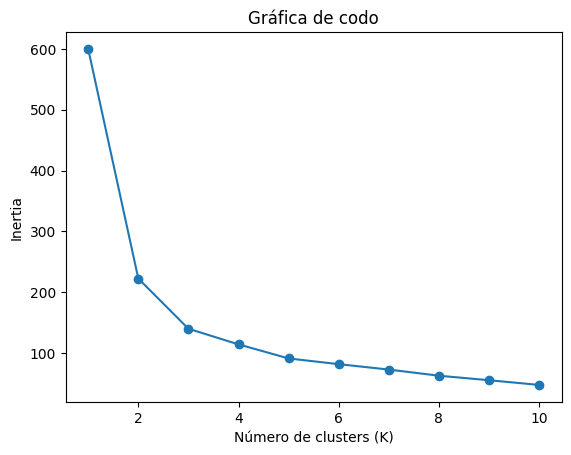

In [10]:
inertias = []

K_values = range(1, 11)

for k in K_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_scaled)
    inertias.append(model.inertia_)

plt.plot(K_values, inertias, marker="o")
plt.xlabel("Número de clusters (K)")
plt.ylabel("Inertia")
plt.title("Gráfica de codo")
plt.show()

### Preguntas de reflexión

8. ¿En qué valor de K parece estar el “codo”?
    > entre 2 y 4
9. ¿Por qué la inertia siempre baja cuando K aumenta?
    > Por que hace que eventualmente cada punto tenga su propio grupo
10. ¿Por qué no conviene usar un K demasiado grande?
    > Por que no estaríamos clasificando nada significativo

## 10. Silhouette Score

El `silhouette score` mide qué tan bien separado está cada punto de otros clusters.

Interpretación aproximada:

- cercano a 1: clusters bien separados
- cercano a 0: clusters solapados
- negativo: puntos posiblemente mal asignados

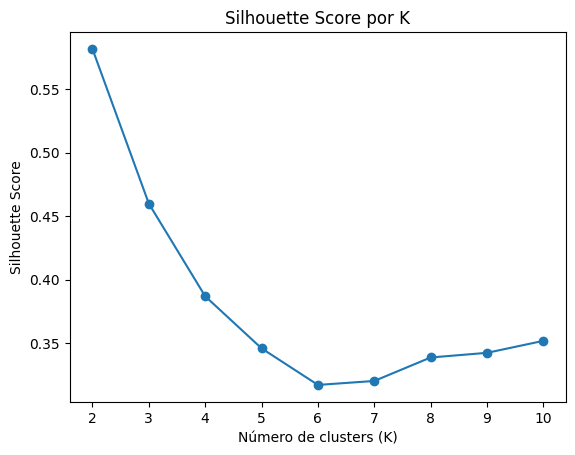

,K,Silhouette Score
0,2,0.581750
1,3,0.459948
2,4,0.386941
3,5,0.345901
4,6,0.317079
5,7,0.320197
6,8,0.338692
7,9,0.342360
8,10,0.351793


In [11]:
silhouette_scores = []

K_values = range(2, 11)

for k in K_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

plt.plot(K_values, silhouette_scores, marker="o")
plt.xlabel("Número de clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score por K")
plt.show()

pd.DataFrame({
    "K": list(K_values),
    "Silhouette Score": silhouette_scores
})

### Preguntas de reflexión

11. ¿Qué K obtuvo el mejor silhouette score?
    > 2
12. ¿Coincide con la gráfica de codo?
    > Mas o menos
13. Si no coincide, ¿cuál elegirías y por qué?
    > Las dos son buenas, pero me convence más la segunda, ya que parece tener más precisión

## 11. PCA para visualización

Iris tiene 4 variables numéricas.  
Para visualizar en 2D, reduciremos a 2 componentes principales.

In [12]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["cluster"] = clusters
pca_df["species"] = y_real

pca_df.head()

,PC1,PC2,cluster,species
0,-2.264703,0.480027,1,0
1,-2.080961,-0.674134,1,0
2,-2.364229,-0.341908,1,0
3,-2.299384,-0.597395,1,0
4,-2.389842,0.646835,1,0


In [13]:
print("Varianza explicada por cada componente:")
print(pca.explained_variance_ratio_)

print("Varianza total explicada:")
print(pca.explained_variance_ratio_.sum())

Varianza explicada por cada componente:
[0.72962445 0.22850762]
Varianza total explicada:
0.9581320720000165


### Reflexión

14. ¿Qué significa que los dos componentes expliquen cierta proporción de la varianza?
    > Que se tienen dos varibles relacionadas que se pueden expresar en una sola
15. ¿Qué se gana y qué se pierde al reducir de 4 dimensiones a 2?
    > Se gana rapidez y menos complejidad. Se pierde precisión y certeza

## 12. Visualizar clusters con PCA

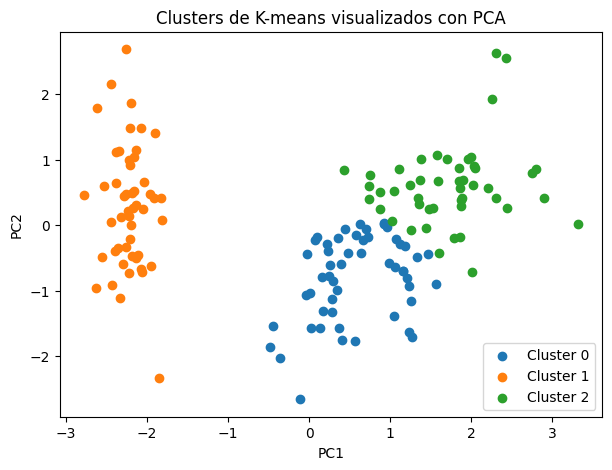

In [14]:
plt.figure(figsize=(7,5))

for cluster in sorted(pca_df["cluster"].unique()):
    subset = pca_df[pca_df["cluster"] == cluster]
    plt.scatter(subset["PC1"], subset["PC2"], label=f"Cluster {cluster}")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Clusters de K-means visualizados con PCA")
plt.legend()
plt.show()

## 13. Comparar contra etiquetas reales

Recuerda: K-means no usó estas etiquetas para entrenar.  
Las usamos solo para comparar visualmente.

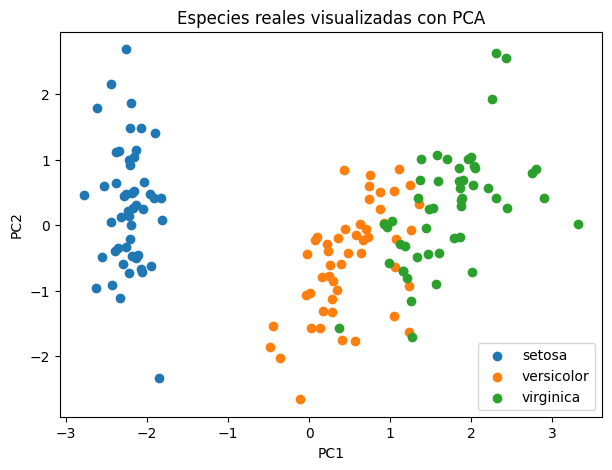

In [15]:
plt.figure(figsize=(7,5))

for species in sorted(pca_df["species"].unique()):
    subset = pca_df[pca_df["species"] == species]
    plt.scatter(subset["PC1"], subset["PC2"], label=iris.target_names[species])

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Especies reales visualizadas con PCA")
plt.legend()
plt.show()

### Preguntas de reflexión

16. ¿Los clusters se parecen a las especies reales?
    > Sí
17. ¿Qué especie parece separarse mejor?
    > La setosa
18. ¿Qué nos dice esto sobre K-means?
    > Que existe un grupo separado de los otros dos, y los grupos que están cerca pueden confundirse a veces

# Parte autónoma — Base de datos Pokémon

Ahora trabajarás con una base de datos de Pokémon (https://www.kaggle.com/datasets/abcsds/pokemon).

## Instrucciones

1. Descarga una base de datos de Pokémon de Kaggle.
2. Sube el archivo al entorno del notebook.
3. Renómbralo como `pokemon.csv`.
4. Ejecuta las celdas.
5. Completa los ejercicios.

Sugerencia de columnas útiles si existen en tu archivo:

- `HP`
- `Attack`
- `Defense`
- `Sp. Atk`
- `Sp. Def`
- `Speed`
- `Total`

Si los nombres de columnas son diferentes, ajusta el código.

## 14. Cargar Pokémon

In [18]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("abcsds/pokemon")

print("Path to dataset files:", path)

Path to dataset files: /Users/alonso284/.cache/kagglehub/datasets/abcsds/pokemon/versions/2


In [19]:
# Ejecuta esta celda cuando ya tengas pokemon.csv en el entorno.
pokemon = pd.read_csv("pokemon.csv")

pokemon.head()

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False


## 15. Explorar columnas

In [20]:
pokemon.info()

<class 'pandas.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   #           800 non-null    int64
 1   Name        800 non-null    str  
 2   Type 1      800 non-null    str  
 3   Type 2      414 non-null    str  
 4   Total       800 non-null    int64
 5   HP          800 non-null    int64
 6   Attack      800 non-null    int64
 7   Defense     800 non-null    int64
 8   Sp. Atk     800 non-null    int64
 9   Sp. Def     800 non-null    int64
 10  Speed       800 non-null    int64
 11  Generation  800 non-null    int64
 12  Legendary   800 non-null    bool 
dtypes: bool(1), int64(9), str(3)
memory usage: 75.9 KB


In [21]:
pokemon.describe()

,#,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation
count,800.000000,800.00000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.00000
mean,362.813750,435.10250,69.258750,79.001250,73.842500,72.820000,71.902500,68.277500,3.32375
std,208.343798,119.96304,25.534669,32.457366,31.183501,32.722294,27.828916,29.060474,1.66129
min,1.000000,180.00000,1.000000,5.000000,5.000000,10.000000,20.000000,5.000000,1.00000
25%,184.750000,330.00000,50.000000,55.000000,50.000000,49.750000,50.000000,45.000000,2.00000
50%,364.500000,450.00000,65.000000,75.000000,70.000000,65.000000,70.000000,65.000000,3.00000
75%,539.250000,515.00000,80.000000,100.000000,90.000000,95.000000,90.000000,90.000000,5.00000
max,721.000000,780.00000,255.000000,190.000000,230.000000,194.000000,230.000000,180.000000,6.00000


## Ejercicio 1 — Selección de variables

Selecciona variables numéricas para agrupar Pokémon.

Puedes empezar con:

```python
features = ["HP", "Attack", "Defense", "Sp. Atk", "Sp. Def", "Speed"]
```

Ajusta los nombres si tu dataset usa otros nombres.

In [22]:
# Completa o ajusta esta lista según las columnas disponibles
features = ["HP", "Attack", "Defense", "Sp. Atk", "Sp. Def", "Speed"]

X_pokemon = pokemon[features]

# Revisa si hay datos faltantes
X_pokemon.isnull().sum()

HP         0
Attack     0
Defense    0
Sp. Atk    0
Sp. Def    0
Speed      0
dtype: int64

Si hay datos faltantes, decide qué hacer.  
Una opción sencilla es eliminar esas filas:

In [23]:
X_pokemon = X_pokemon.dropna()

X_pokemon.head()

,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed
0,45,49,49,65,65,45
1,60,62,63,80,80,60
2,80,82,83,100,100,80
3,80,100,123,122,120,80
4,39,52,43,60,50,65


## Ejercicio 2 — Escalamiento

Escala los datos de Pokémon antes de usar K-means.

In [24]:
# Completa el escalamiento

scaler_pokemon = StandardScaler()

X_pokemon_scaled = scaler_pokemon.fit_transform(X_pokemon)

X_pokemon_scaled[:5]

array([[-0.95062622, -0.92490618, -0.79715364, -0.2391303 , -0.24818854,
        -0.80150318],
       [-0.3628221 , -0.5241302 , -0.34791742,  0.21955954,  0.29115635,
        -0.28501525],
       [ 0.42091674,  0.09244823,  0.29384863,  0.83114599,  1.01028289,
         0.40363531],
       [ 0.42091674,  0.64736882,  1.57738071,  1.50389108,  1.72940942,
         0.40363531],
       [-1.18574787, -0.83241942, -0.98968346, -0.39202691, -0.78753344,
        -0.11285261]])

## Ejercicio 3 — Gráfica de codo

Construye una gráfica de codo para K entre 1 y 10.

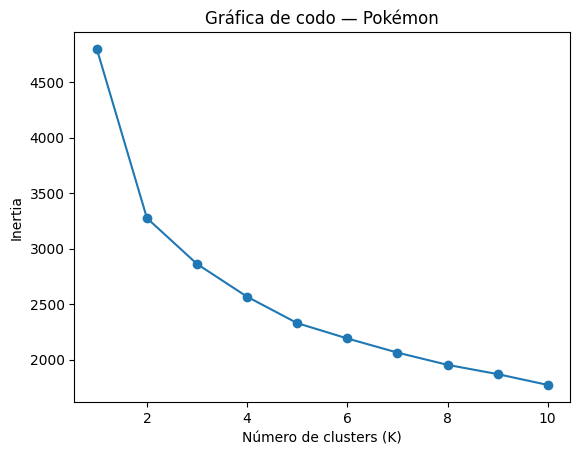

In [ ]:
# Completa el código

pokemon_inertias = []
K_values = range(1, 11)

for k in K_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_pokemon_scaled)
    pokemon_inertias.append(model.inertia_)

plt.plot(K_values, pokemon_inertias, marker="o")
plt.xlabel("Número de clusters (K)")
plt.ylabel("Inertia")
plt.title("Gráfica de codo — Pokémon")
plt.show()

### Reflexión

19. ¿Qué valor de K elegirías con la gráfica de codo?
    > 3
20. ¿El codo es claro o ambiguo?
    > Veo un rango claro

## Ejercicio 4 — Silhouette Score

Calcula silhouette score para K entre 2 y 10.

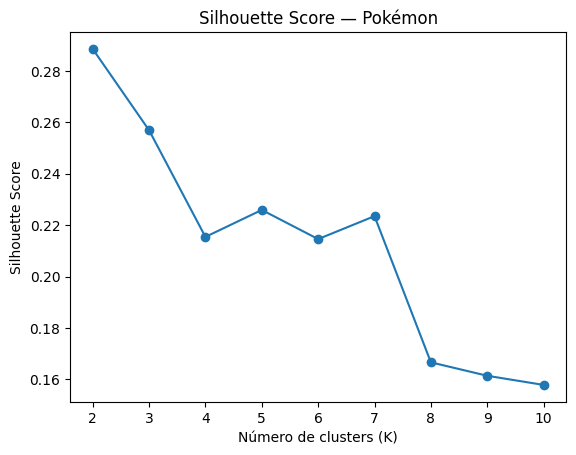

,K,Silhouette Score
0,2,0.288577
1,3,0.256934
2,4,0.215408
3,5,0.225908
4,6,0.214563
5,7,0.223496
6,8,0.166592
7,9,0.161365
8,10,0.157802


In [26]:
# Completa el código

pokemon_silhouette = []
K_values = range(2, 11)

for k in K_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X_pokemon_scaled)
    score = silhouette_score(X_pokemon_scaled, labels)
    pokemon_silhouette.append(score)

plt.plot(K_values, pokemon_silhouette, marker="o")
plt.xlabel("Número de clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score — Pokémon")
plt.show()

pd.DataFrame({
    "K": list(K_values),
    "Silhouette Score": pokemon_silhouette
})

### Reflexión

21. ¿Qué K tiene mejor silhouette score?
    > 2
22. ¿Elegirías ese K? ¿Por qué?
    > Sí, tengo fé

## Ejercicio 5 — Entrenar K-means con tu K elegido

Elige un valor de K y entrena el modelo final.

In [27]:
# Elige tu K
best_k = 2

pokemon_kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)

pokemon_clusters = pokemon_kmeans.fit_predict(X_pokemon_scaled)

pokemon_result = pokemon.copy()
pokemon_result = pokemon_result.loc[X_pokemon.index].copy()
pokemon_result["cluster"] = pokemon_clusters

pokemon_result.head()

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary,cluster
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False,0
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False,0
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False,1
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False,1
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False,0


## Ejercicio 6 — PCA para visualizar Pokémon

Reduce los datos a 2 componentes principales.

In [29]:
# Completa el PCA

pca_pokemon = PCA(n_components=2)

pokemon_pca = pca_pokemon.fit_transform(X_pokemon_scaled)

pokemon_pca_df = pd.DataFrame(pokemon_pca, columns=["PC1", "PC2"])
pokemon_pca_df["cluster"] = pokemon_clusters

pokemon_pca_df.head()

,PC1,PC2,cluster
0,-1.556375,0.021482,0
1,-0.362867,0.050269,0
2,1.280152,0.062720,1
3,2.620916,-0.704263,1
4,-1.758284,0.706179,0


In [30]:
print("Varianza explicada:")
print(pca_pokemon.explained_variance_ratio_)

print("Varianza total explicada:")
print(pca_pokemon.explained_variance_ratio_.sum())

Varianza explicada:
[0.45190665 0.18225358]
Varianza total explicada:
0.6341602266029072


## Ejercicio 7 — Visualización final

Grafica los clusters de Pokémon en el espacio PCA.

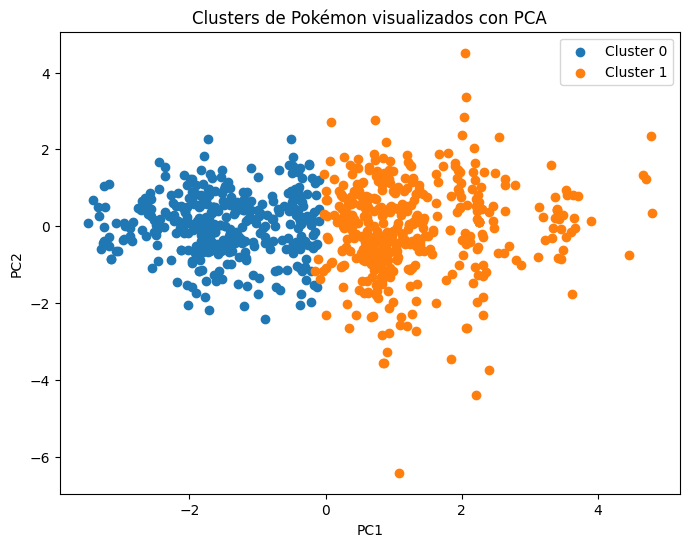

In [31]:
plt.figure(figsize=(8,6))

for cluster in sorted(pokemon_pca_df["cluster"].unique()):
    subset = pokemon_pca_df[pokemon_pca_df["cluster"] == cluster]
    plt.scatter(subset["PC1"], subset["PC2"], label=f"Cluster {cluster}")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Clusters de Pokémon visualizados con PCA")
plt.legend()
plt.show()

## Reflexión final

23. ¿Qué parecen representar los clusters?
    > No creo que exista una separación clara entre los dos clusters
24. ¿Hay grupos de Pokémon con características similares?
    > Según esta gráfica, todos tienen al menos otro parecido
25. ¿Qué variables crees que influyeron más en los grupos?
    > Ataque y defensa
26. ¿Qué limitaciones tiene este análisis?
    >  Se limita a valores numéricos continuos
27. ¿Qué cambiarías para mejorar el agrupamiento?
    > Agregar más variables, como sus habilidades